# ABCD with Outliers and Overlaps (ABCD+o2)

Another extension of the ABCD model allows nodes to be in multiple communities: overlapping communities. This extension build on ABCD+o, so outliers are also allowed ([read the ABCD+o notebook here](outliers.ipynb)). The ABCD+o2 extension adds two new key parameters
- $\eta$ (eta): the average number of communities per non-outlier node
- $\rho$ (rho): the pearson correlation between the number of communities a node is in and its degree.

By default, these values are set to 1.0 and 0.0 respectively, which creates no overlap and makes ABCD+o2 equivalent to ABCD+o.

In [1]:
from abcd_graph import ABCD

abcd = ABCD(1000, eta=1.5, rho=0.3)
sample = abcd.sample()

sample.eta

np.float64(1.5)

The community information is stored in the `membership_matrix` property of the sample. It is a sparse boolean matrix with rows representing communities and columns representing vertices. A True (or 1) value means that community contains that node. Not many community detection libraries are built to handle communities with overlaps and/or outliers, so we leave it up to you to work with this membership matrix directly.

In [2]:
sample.membership_matrix

<Compressed Sparse Row sparse array of dtype 'bool'
	with 1500 stored elements and shape (28, 1000)>

## How it works

Once we have an assignment of nodes to communities and degrees to nodes the ABCD+o2 sampling is fairly simple. The non-background degree (recall each vertex has xi proportion of its degree in the background graph) of each vertex will be split evenly among the communities to which it belongs, and community generation and rewiring proceed as normal.

### Assigning Overlapping Communities
The first challenge is assigning nodes to communities so that there is realistic overlap pattern, and our proposal is to use a hidden geometric reference layer. We assume that we have a number of non-outlier nodes $\hat{n}$, and a sequence of community sizes $C_1, C_2, ... C_j$, such that $\sum_{i \in 1 .. j} C_i / \hat{n} = \eta$. We shrink each community by a factor of $\eta$ to get a primary community size $\hat{C}_i$ (randomly rounded to an integer), and make small fixes so that $\sum_{i \in 1 ... j} \hat{C}_i = \hat{n}$.

Next, we use the hidden reference layer to assign each vertex to exactly one primary community. We randomly sample $\hat{n}$ vectors uniformly from a unit ball in dimension $d$ (another new model parameter) and assign each to a vertex. For each primary community size, in decreasing order of size, we take the vertex furthest from the centre that does not yet have a primary community, and assign it and it's nearest non-assigned neighbors to this primary community. After all primary communities are assigned, we expand each community back to it's initial size by adding nearest neighbors to it's centre of mass.

![Picking the further point for the origin as the seed of the next community](_static/overlap_geom.png)

Example of building the community $C_3$ with $\hat{C}_3 = 40$ and $\eta = 1.75$ using a 2D reference layer. First, in panel (A), we select the seed as the vector furthest from the origin that does not have a primary  community. Next (panel B), we build the primary community $\hat{C}_3$ as a node of the seed and the nodes of the seed’s $\hat{C}_3 − 1$ nearest neighbours that do not yet have a primary community. Finally, in panel (C), we create $C_3$ by expanding $\hat{C}_3$ by a factor of $\eta$ (from $40$ to $40 \cdot 1.75 = 70$ nodes) by taking the nearest neighbours to the primary centre of mass. Image from [Barret et.al (2026)](https://doi.org/10.1093/comnet/cnag023).

### Assigning Degrees

Now that we have each node assigned to 0, 1, or several communities, we have to assign each node a degree. There are a few conditions on which degrees can get assigned to each node depending on the nodes communities, though in practice these conditions are not very strict so we will ignore them here (and refer to the paper for full details). The main challenge is assigning degrees to vertices so that the pearson correlation between the number of communities to which a node belongs and its degree, restricted to non-outlier nodes, is $\rho$.

This problem is hard, so we instead take a "guess and check" approach to tuning an internal parameter $\alpha$. We assign degrees sequentially in decreasing order, and we decide which node will get the current degree by choosing a random viable vertex with probabilities proportional to the number of communities the nodes is in to the power $\alpha$. That is, if node $i$ is in $\eta_i$ communities its probability is proportional to $\eta_i ^ \alpha$. This way we can tune $\alpha$ to get a positive or negative correlation. We simply run a binary search on $\alpha$ until we get an acceptable degree assignment.

## Benchmarking Community Detection Algorithms with ABCD+o2

There are not many algorithms that allow both outliers and overlaps, and several of the existing ones don't have readily available python implementations. So, for simplicity we will only benchmark the Egosplit algorithm using *not-official* [egosplit-sknetwork](https://github.com/ryandewolfe33/egosplit-sknetwork) implementation.

A non-exhaustive list of other algorithms include:
- Order Statistics Local Optimization Method (OSLOM): [Paper](https://doi.org/10.1371/journal.pone.0018961), [Code](http://www.oslom.org/)
- Hierarchical Single Linkage Edge Clustering: [Paper](https://doi.org/10.1007/978-3-032-16719-4_8)

For comparing the similarity between the detected communities and the ground truth, we will use the recently developed [F* score]( https://doi.org/10.48550/arXiv.2602.14855) that was designed explicitly to handle outliers and overlaps.



In [3]:
import matplotlib.pyplot as plt
import numpy as np
from egosplit_sknetwork import EgoSplit
from Fstar import fstar

In [4]:
xis = [0.2, 0.25, 0.3, 0.35, 0.4]
etas = [1., 1.25, 1.5, 1.75, 2.]
reps = 10

abcd = ABCD(1000, rng=np.random.default_rng(seed=42))
egosplit = EgoSplit(global_clustering="PC", random_state=42)
fs = np.empty((len(xis), len(etas), reps))

for i, xi in enumerate(xis):
    abcd.xi = xi
    for j, eta in enumerate(etas):
        abcd.eta = eta
        for k in range(reps):
            sample = abcd.sample()
            predict = egosplit.fit_predict(sample.to_sparse(matrix=True))
            fs[i,j,k] = fstar(sample.membership_matrix, predict)

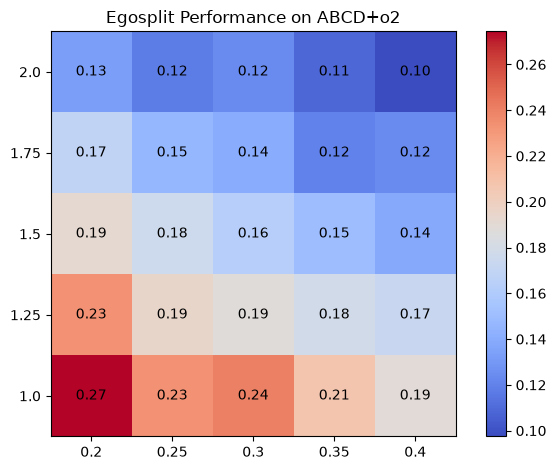

In [9]:
fs_mean = np.mean(fs, axis=2)[::-1]

fig, ax = plt.subplots()
im = ax.imshow(fs_mean, cmap='coolwarm')
cbar = ax.figure.colorbar(im, ax=ax)
ax.set_xticks(np.arange(len(xis)), xis)
ax.set_yticks(np.arange(len(etas)), etas[::-1])
for i in range(len(xis)):
    for j in range(len(etas)):
        text = ax.text(j, i, f"{fs_mean[i, j]:.2f}",
                       ha="center", va="center", color="black")
ax.set_title("Egosplit Performance on ABCD+o2")
fig.tight_layout()

## References
ABCD+o2
- [Jordan Barrett, Ryan DeWolfe, Bogumił Kamiński, Paweł Prałat, Aaron Smith, and François Théberge. The artificial benchmark for community detection with outliers and overlapping communities (abcd+o2). Journal of Complex Networks 14(4):cnag023 (2026) doi: 10.1093/comnet/cnag023](https://doi.org/10.1093/comnet/cnag023)

Egosplit
- [Alessandro Epasto, Silvio Lattanzi, and Renato Paes Leme. Ego-Splitting Framework: from Non-Overlapping to Overlapping Clusters. In Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '17) doi: 10.1145/3097983.3098054](https://doi.org/10.1145/3097983.3098054)

F*
- [Ryan DeWolfe, Paweł Prałat, François Théberge. A Pragmatic Method for Comparing Clusterings with Overlaps and Outliers. arxiv preprint (2026) doi: 10.48550/arXiv.2602.14855](https://doi.org/10.48550/arXiv.2602.14855)